In [1]:
import glob, shutil, os, hashlib, random, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import cohen_kappa_score
from collections import OrderedDict
import math

target_pattern = "../input/efficientnet*/efficientNet_*.pth"
targets = glob.glob(target_pattern)
model_path = "efficientNet_best.pth"
if targets:
    shutil.copy(targets[0], model_path)
    md5 = hashlib.md5()
    with open(model_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            md5.update(chunk)
    print(f"MD5({model_path}) = {md5.hexdigest()}")
else:
    print(
        "No pretrained EfficientNet weights found; proceeding with randomly initialized model."
    )




No pretrained EfficientNet weights found; proceeding with randomly initialized model.


In [2]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class Flatten(nn.Module):
    def forward(self, x):
        return x.reshape(x.shape[0], -1)


class SqueezeExcitation(nn.Module):
    def __init__(self, inplanes, se_planes):
        super(SqueezeExcitation, self).__init__()
        self.reduce_expand = nn.Sequential(
            nn.Conv2d(
                inplanes, se_planes, kernel_size=1, stride=1, padding=0, bias=True
            ),
            Swish(),
            nn.Conv2d(
                se_planes, inplanes, kernel_size=1, stride=1, padding=0, bias=True
            ),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x_se = torch.mean(x, dim=(-2, -1), keepdim=True)
        x_se = self.reduce_expand(x_se)
        return x_se * x


class MBConv(nn.Module):
    def __init__(
        self,
        inplanes,
        planes,
        kernel_size,
        stride,
        expand_rate=1.0,
        se_rate=0.25,
        drop_connect_rate=0.2,
    ):
        super(MBConv, self).__init__()
        expand_planes = int(inplanes * expand_rate)
        se_planes = max(1, int(inplanes * se_rate))

        self.expansion_conv = None
        if expand_rate > 1.0:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    expand_planes,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=False,
                ),
                nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
                Swish(),
            )
            inplanes = expand_planes

        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(
                inplanes,
                expand_planes,
                kernel_size=kernel_size,
                stride=stride,
                padding=kernel_size // 2,
                groups=expand_planes,
                bias=False,
            ),
            nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
            Swish(),
        )
        self.squeeze_excitation = SqueezeExcitation(expand_planes, se_planes)
        self.project_conv = nn.Sequential(
            nn.Conv2d(
                expand_planes, planes, kernel_size=1, stride=1, padding=0, bias=False
            ),
            nn.BatchNorm2d(planes, momentum=0.01, eps=1e-3),
        )
        self.with_skip = stride == 1
        self.drop_connect_rate = torch.tensor(drop_connect_rate, requires_grad=False)

    def _drop_connect(self, x):
        keep_prob = 1.0 - self.drop_connect_rate
        drop_mask = torch.rand(x.shape[0], 1, 1, 1, device=x.device) + keep_prob
        drop_mask = drop_mask.floor_()
        return drop_mask * x / keep_prob

    def forward(self, x):
        z = x
        if self.expansion_conv is not None:
            x = self.expansion_conv(x)
        x = self.depthwise_conv(x)
        x = self.squeeze_excitation(x)
        x = self.project_conv(x)
        if x.shape == z.shape and self.with_skip:
            if self.training and self.drop_connect_rate is not None:
                x = self._drop_connect(x)
            x = x + z
        return x


def init_weights(module):
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, a=0, mode="fan_out")
    elif isinstance(module, nn.Linear):
        init_range = 1.0 / math.sqrt(module.weight.shape[1])
        nn.init.uniform_(module.weight, a=-init_range, b=init_range)


class EfficientNet(nn.Module):
    def _setup_repeats(self, num_repeats):
        return int(math.ceil(self.depth_coefficient * num_repeats))

    def _setup_channels(self, num_channels):
        num_channels *= self.width_coefficient
        new_num_channels = math.floor(num_channels / self.divisor + 0.5) * self.divisor
        new_num_channels = max(self.divisor, new_num_channels)
        if new_num_channels < 0.9 * num_channels:
            new_num_channels += self.divisor
        return new_num_channels

    def __init__(
        self,
        num_classes,
        width_coefficient=1.0,
        depth_coefficient=1.0,
        se_rate=0.25,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
    ):
        super(EfficientNet, self).__init__()
        self.width_coefficient = width_coefficient
        self.depth_coefficient = depth_coefficient
        self.divisor = 8
        list_channels = [32, 16, 24, 40, 80, 112, 192, 320, 1280]
        list_channels = [self._setup_channels(c) for c in list_channels]
        list_num_repeats = [1, 2, 2, 3, 3, 4, 1]
        list_num_repeats = [self._setup_repeats(r) for r in list_num_repeats]
        expand_rates = [1, 6, 6, 6, 6, 6, 6]
        strides = [1, 2, 2, 2, 1, 2, 1]
        kernel_sizes = [3, 3, 5, 3, 5, 5, 3]

        self.stem = nn.Sequential(
            nn.Conv2d(
                3, list_channels[0], kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm2d(list_channels[0], momentum=0.01, eps=1e-3),
            Swish(),
        )
        blocks = []
        counter = 0
        num_blocks = sum(list_num_repeats)
        for idx in range(7):
            num_channels = list_channels[idx]
            next_num_channels = list_channels[idx + 1]
            num_repeats = list_num_repeats[idx]
            expand_rate = expand_rates[idx]
            kernel_size = kernel_sizes[idx]
            stride = strides[idx]
            drop_rate = drop_connect_rate * counter / num_blocks
            name = f"MBConv{expand_rate}_{counter}"
            blocks.append(
                (
                    name,
                    MBConv(
                        num_channels,
                        next_num_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        expand_rate=expand_rate,
                        se_rate=se_rate,
                        drop_connect_rate=drop_rate,
                    ),
                )
            )
            counter += 1
            for i in range(1, num_repeats):
                name = f"MBConv{expand_rate}_{counter}"
                drop_rate = drop_connect_rate * counter / num_blocks
                blocks.append(
                    (
                        name,
                        MBConv(
                            next_num_channels,
                            next_num_channels,
                            kernel_size=kernel_size,
                            stride=1,
                            expand_rate=expand_rate,
                            se_rate=se_rate,
                            drop_connect_rate=drop_rate,
                        ),
                    )
                )
                counter += 1
        self.blocks = nn.Sequential(OrderedDict(blocks))
        self.head = nn.Sequential(
            nn.Conv2d(list_channels[-2], list_channels[-1], kernel_size=1, bias=False),
            nn.BatchNorm2d(list_channels[-1], momentum=0.01, eps=1e-3),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(list_channels[-1], num_classes),
        )
        self.apply(init_weights)

    def forward(self, x):
        f = self.stem(x)
        f = self.blocks(f)
        y = self.head(f)
        return y




In [3]:
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = EfficientNet(num_classes=5)
if os.path.exists(model_path):
    try:
        best_model.load_state_dict(torch.load(model_path, map_location=device))
        print("Pretrained weights loaded.")
    except Exception as e:
        print(f"Failed to load pretrained weights: {e}")
else:
    print("Model weight file not found; using randomly initialized model.")
best_model = best_model.to(device)




Model weight file not found; using randomly initialized model.


In [4]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
from PIL import Image

image_size = 224
base_transform = Compose(
    [
        Resize((image_size, image_size), Image.BICUBIC),
        ToTensor(),
        Normalize(mean=[0.42, 0.22, 0.075], std=[0.27, 0.15, 0.081]),
    ]
)


class InMemoryImageDataset(torch.utils.data.Dataset):
    """
    Loads all images once into memory as pre‑processed tensors.
    For training, a horizontal flip is applied on‑the‑fly to preserve randomness.
    """

    def __init__(self, root, path_list, targets=None, apply_flip=False):
        self.root = root
        self.path_list = path_list
        self.apply_flip = apply_flip
        if targets is not None:
            self.targets = torch.LongTensor(targets)
        else:
            self.targets = None

        self.tensors = []
        for p in path_list:
            img_path = os.path.join(self.root, p + ".png")
            img = Image.open(img_path).convert("RGB")
            self.tensors.append(base_transform(img))

    def __getitem__(self, idx):
        x = self.tensors[idx]
        if self.apply_flip and torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[2])  # horizontal flip on width dimension
        if self.targets is not None:
            return x, self.targets[idx]
        else:
            return x, torch.LongTensor([])

    def __len__(self):
        return len(self.tensors)


df_test = pd.read_csv("../input/aptos2019-blindness-detection/test.csv")
test_dataset = InMemoryImageDataset(
    root="../input/aptos2019-blindness-detection/test_images",
    path_list=df_test.id_code.values,
    apply_flip=False,
)

df_train = pd.read_csv("../input/aptos2019-blindness-detection/train.csv")
full_train_dataset = InMemoryImageDataset(
    root="../input/aptos2019-blindness-detection/train_images",
    path_list=df_train.id_code.values,
    targets=df_train.diagnosis.values,
    apply_flip=True,  # enable random horizontal flip during training
)

# compute class‑balancing weights
class_counts = np.bincount(df_train.diagnosis.values, minlength=5)
class_weights = torch.tensor(len(df_train) / (5 * class_counts), dtype=torch.float).to(
    device
)

val_ratio = 0.10
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 64
num_workers = max(1, os.cpu_count() or 0)
print("num_workers:", num_workers)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=True,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    persistent_workers=True,
)




num_workers: 32


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

best_model.train()
criterion = nn.CrossEntropyLoss(weight=class_weights)  # balanced loss
optimizer = optim.Adam(best_model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, verbose=True, min_lr=1e-5
)

scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

epochs = 30  # more epochs for modest improvement
best_kappa = -1.0

for epoch in range(1, epochs + 1):
    best_model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = best_model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = best_model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} - Training loss: {epoch_loss:.4f}")

    best_model.eval()
    all_val_preds, all_val_true = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = best_model(imgs)
            else:
                outputs = best_model(imgs)
            preds = torch.argmax(outputs, dim=1)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_true.extend(labels.cpu().numpy())
    val_kappa = cohen_kappa_score(all_val_true, all_val_preds, weights="quadratic")
    print(f"Epoch {epoch} - Validation Quadratic Weighted Kappa: {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(best_model.state_dict(), "best_tmp.pth")
        print(f"New best model saved (kappa={best_kappa:.4f})")

    scheduler.step(val_kappa)

print(f"Training complete. Best validation kappa: {best_kappa:.4f}")

best_model.load_state_dict(torch.load("best_tmp.pth", map_location=device))
best_model.eval()




/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_55/1007655772.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None
/tmp/ipykernel_55/1007655772.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30 - Training loss: 1.6075


/tmp/ipykernel_55/1007655772.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 - Validation Quadratic Weighted Kappa: 0.0000
New best model saved (kappa=0.0000)


/tmp/ipykernel_55/1007655772.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

/tmp/ipykernel_55/1007655772.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_55/1007655772.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 30/30 - Training loss: 0.4764


/tmp/ipykernel_55/1007655772.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 30 - Validation Quadratic Weighted Kappa: 0.7378
New best model saved (kappa=0.7378)
Training complete. Best validation kappa: 0.7378


EfficientNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Swish()
  )
  (blocks): Sequential(
    (MBConv1_0): MBConv(
      (depthwise_conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
      )
      (squeeze_excitation): SqueezeExcitation(
        (reduce_expand): Sequential(
          (0): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (1): Swish()
          (2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (3): Sigmoid()
        )
      )
      (project_conv): Sequential(
        (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, tr

In [6]:
from tqdm import tqdm

all_pred = []
with torch.no_grad():
    for x, _ in tqdm(test_loader, total=len(test_loader)):
        x = x.to(device, non_blocking=True)
        if scaler:
            with torch.cuda.amp.autocast():
                y_pred1 = best_model(x)
                y_pred2 = best_model(torch.flip(x, dims=(-1,)))
        else:
            y_pred1 = best_model(x)
            y_pred2 = best_model(torch.flip(x, dims=(-1,)))
        prob_avg = 0.5 * (F.softmax(y_pred1, dim=-1) + F.softmax(y_pred2, dim=-1))
        preds = torch.argmax(prob_avg, dim=1)
        all_pred.extend(preds.cpu().numpy().tolist())
print(f"Collected predictions for {len(all_pred)} images.")




  0%|          | 0/6 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipykernel_55/2435439206.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 6/6 [00:02<00:00,  2.01it/s]

Collected predictions for 367 images.


In [7]:
sub = pd.read_csv("../input/aptos2019-blindness-detection/sample_submission.csv")
if len(all_pred) != len(sub):
    raise ValueError(
        f"Prediction length {len(all_pred)} does not match submission rows {len(sub)}"
    )
sub["diagnosis"] = np.array(all_pred, dtype=int)
sub.to_csv("submission.csv", index=False)
print("Submission saved as submission.csv")
sub.head()




Submission saved as submission.csv


,id_code,diagnosis
0,b460ca9fa26f,0
1,6cee2e148520,0
2,ca6842bfcbc9,1
3,6cbc3dad809c,2
4,a9bc2f892cb3,0


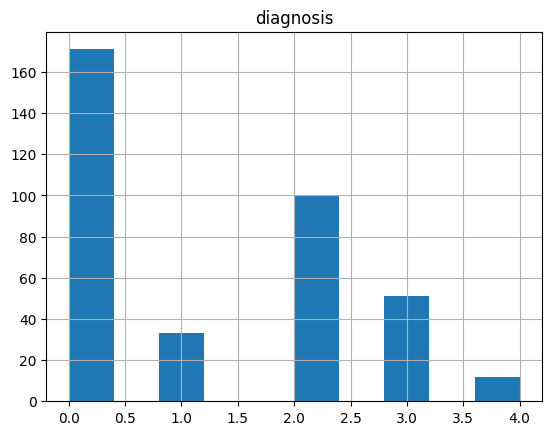

In [8]:
_ = sub.hist()




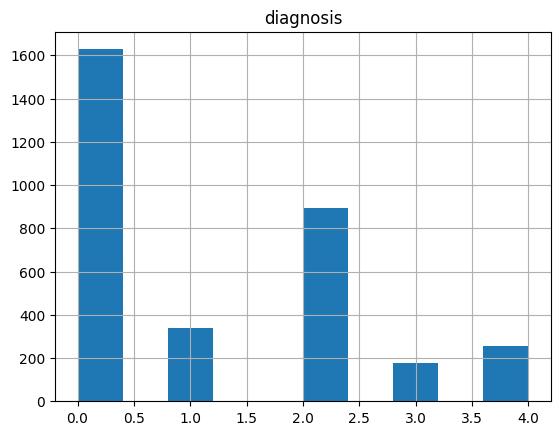

In [9]:
tr = pd.read_csv("../input/aptos2019-blindness-detection/train.csv")
_ = tr.hist()